# Logistics Delivery Performance & Cost Analytics

## Business Problem
The logistics company has operational data but lacks a clear analytical view of delivery performance, delays, route efficiency, warehouse operations, transportation costs, and delivery partner performance.

## Objectives
1. Measure delivery performance.
2. Identify delayed shipments.
3. Understand delay patterns by route/warehouse/mode/partner.
4. Analyze logistics costs.
5. Monitor customer experience.
6. Recommend data-driven operational actions.

In [1]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath(".."))
sns.set_theme(style="whitegrid")
%matplotlib inline

In [2]:
from src.data_loader import load_data
df_raw = load_data("../data/raw/logistics_data.csv")
df_raw.head()

Loaded raw data: 5000 rows x 22 columns


,order_id,customer_id,order_date,warehouse,origin_city,destination_city,distance_km,product_category,quantity,weight_kg,...,shipping_cost,fuel_cost,warehouse_processing_hours,dispatch_date,expected_delivery_date,actual_delivery_date,delivery_status,customer_rating,damage_flag,return_flag
0,ORD101253,CUST12780,2025-03-12,Bengaluru,Bengaluru,Chennai,451.7,Home & Kitchen,7,5.51,...,2044.56,381.66,8.36,2025-03-14,2025-03-19,2025-03-24,Delayed,3.0,No,No
1,ORD102838,CUST11842,2025-12-02,Delhi,Delhi,Surat,592.8,Automotive,1,1.05,...,2582.70,385.02,10.33,2025-12-05,2025-12-12,2025-12-12,Delivered,4.0,No,No
2,ORD103457,CUST10940,2025-04-21,Pune,Pune,Nagpur,191.9,Clothing,3,9.09,...,817.23,185.83,8.88,2025-04-23,2025-04-28,2025-04-28,Delivered,5.0,No,No
3,ORD100061,CUST10263,2025-02-21,Pune,Pune,Coimbatore,376.4,Clothing,7,1.34,...,1713.22,386.35,10.18,2025-02-24,2025-03-02,2025-03-04,Delayed,3.0,No,No
4,ORD103947,CUST12467,2025-08-22,Mumbai,Mumbai,Delhi,895.3,Sports,5,3.95,...,3980.06,990.42,11.17,2025-08-24,2025-08-30,2025-08-30,Delivered,4.0,No,No


In [3]:
print("Shape:", df_raw.shape)
df_raw.info()
df_raw.describe(include="all").T

Shape: (5000, 22)
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   order_id                    5000 non-null   str    
 1   customer_id                 5000 non-null   str    
 2   order_date                  5000 non-null   str    
 3   warehouse                   5000 non-null   str    
 4   origin_city                 5000 non-null   str    
 5   destination_city            4960 non-null   str    
 6   distance_km                 5000 non-null   float64
 7   product_category            5000 non-null   str    
 8   quantity                    5000 non-null   int64  
 9   weight_kg                   5000 non-null   float64
 10  shipping_mode               5000 non-null   str    
 11  delivery_partner            5000 non-null   str    
 12  shipping_cost               4950 non-null   float64
 13  fuel_cost                 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,5000,4975,ORD103311,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,5000,2328,CUST11656,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_date,5000,365,2025-12-15,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
warehouse,5000,12,Hyderabad,1080,NaN,NaN,NaN,NaN,NaN,NaN,NaN
origin_city,5000,6,Hyderabad,1090,NaN,NaN,NaN,NaN,NaN,NaN,NaN
destination_city,4960,18,Indore,333,NaN,NaN,NaN,NaN,NaN,NaN,NaN
distance_km,5000.0,NaN,NaN,NaN,411.09862,260.537306,-25.0,221.775,354.35,541.8,1800.0
product_category,5000,16,Books,659,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quantity,5000.0,NaN,NaN,NaN,3.967,2.009955,0.0,2.0,4.0,6.0,7.0
weight_kg,5000.0,NaN,NaN,NaN,5.528694,3.921885,0.2,2.7,4.64,7.4225,34.09


In [4]:
df_raw.isna().sum().sort_values(ascending=False)
print("Duplicate rows:", df_raw.duplicated().sum())

Duplicate rows: 25


In [5]:
from src.data_cleaner import clean_data, save_cleaned_data
df = clean_data(df_raw)
save_cleaned_data(df, "../data/cleaned/logistics_cleaned.csv")
df.head()

Starting cleaning pipeline...
[MissingValues] Dropped 0 rows missing critical IDs.
[Duplicates] Removed 25 fully duplicated rows.
[Duplicates] Removed 0 duplicated order_ids.
Cleaning complete. Final shape: (4975, 28)
Cleaned data saved to: ../data/cleaned/logistics_cleaned.csv


,order_id,customer_id,order_date,warehouse,origin_city,destination_city,distance_km,product_category,quantity,weight_kg,...,delivery_status,customer_rating,damage_flag,return_flag,delivery_days,delay_days,on_time_flag,delay_status,cost_per_km,total_logistics_cost
0,ORD101253,CUST12780,2025-03-12,Bengaluru,Bengaluru,Chennai,451.7,Home & Kitchen,7.0,5.51,...,Delayed,3.0,No,No,10,5,0.0,Delayed,4.526367,2426.22
1,ORD102838,CUST11842,2025-12-02,Delhi,Delhi,Surat,592.8,Automotive,1.0,1.05,...,Delivered,4.0,No,No,7,0,1.0,On Time,4.356781,2967.72
2,ORD103457,CUST10940,2025-04-21,Pune,Pune,Nagpur,191.9,Clothing,3.0,9.09,...,Delivered,5.0,No,No,5,0,1.0,On Time,4.258624,1003.06
3,ORD100061,CUST10263,2025-02-21,Pune,Pune,Coimbatore,376.4,Clothing,7.0,1.34,...,Delayed,3.0,No,No,8,2,0.0,Delayed,4.551594,2099.57
4,ORD103947,CUST12467,2025-08-22,Mumbai,Mumbai,Delhi,895.3,Sports,5.0,3.95,...,Delivered,4.0,No,No,6,0,1.0,On Time,4.445504,4970.48


In [6]:
from src.business_analysis import *
print("Total Orders:", calculate_total_orders(df))
print("Delivered:", calculate_total_delivered(df))
print("Delayed:", calculate_total_delayed(df))
print("On-Time %:", calculate_on_time_percentage(df))
print("Avg Delivery Days:", calculate_average_delivery_days(df))
print("Avg Delay Days:", calculate_average_delay_days(df))
print("Total Logistics Cost:", calculate_total_logistics_cost(df))
print("Avg Logistics Cost:", calculate_average_logistics_cost(df))
print("Damage Rate %:", calculate_damage_rate(df))
print("Return Rate %:", calculate_return_rate(df))

Total Orders: 4975
Delivered: 3786
Delayed: 1189
On-Time %: 100.0
Avg Delivery Days: 5.63
Avg Delay Days: 2.95
Total Logistics Cost: 13201267.67
Avg Logistics Cost: 2653.52
Damage Rate %: 2.85
Return Rate %: 4.36


c:\Users\user\Downloads\vscode\Logistics Delivery Performance & Cost Analytics\src\visualization.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette="Set2")


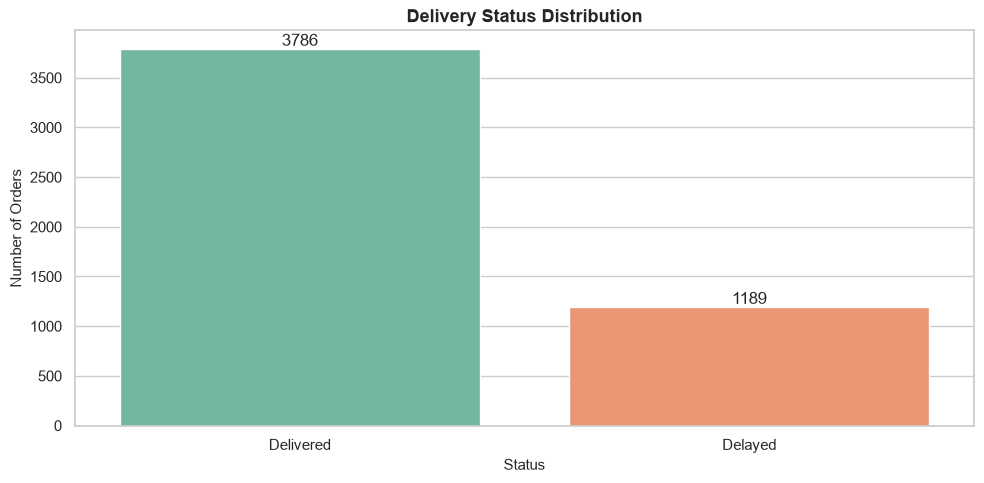

c:\Users\user\Downloads\vscode\Logistics Delivery Performance & Cost Analytics\src\visualization.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=grp.index, y=grp.values, palette="Reds_r")


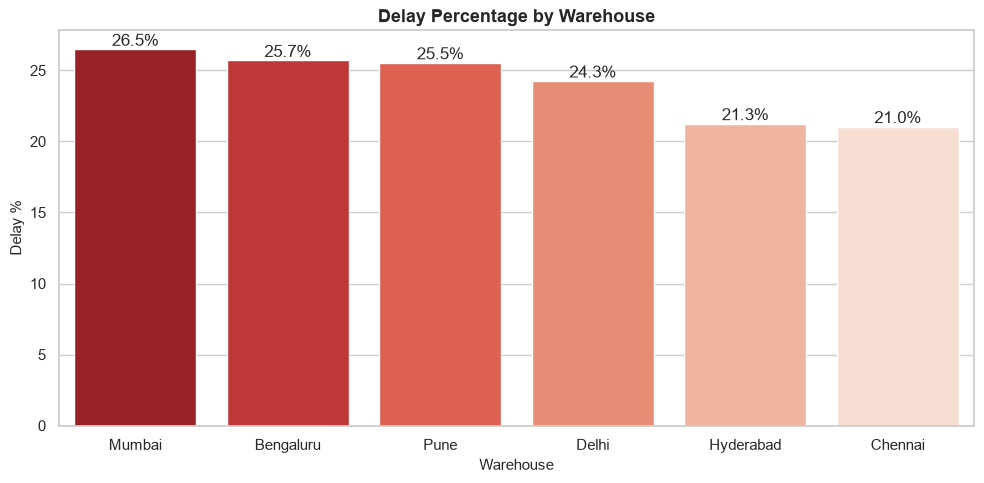

c:\Users\user\Downloads\vscode\Logistics Delivery Performance & Cost Analytics\src\visualization.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=grp.index, y=grp.values, palette="Oranges_r")


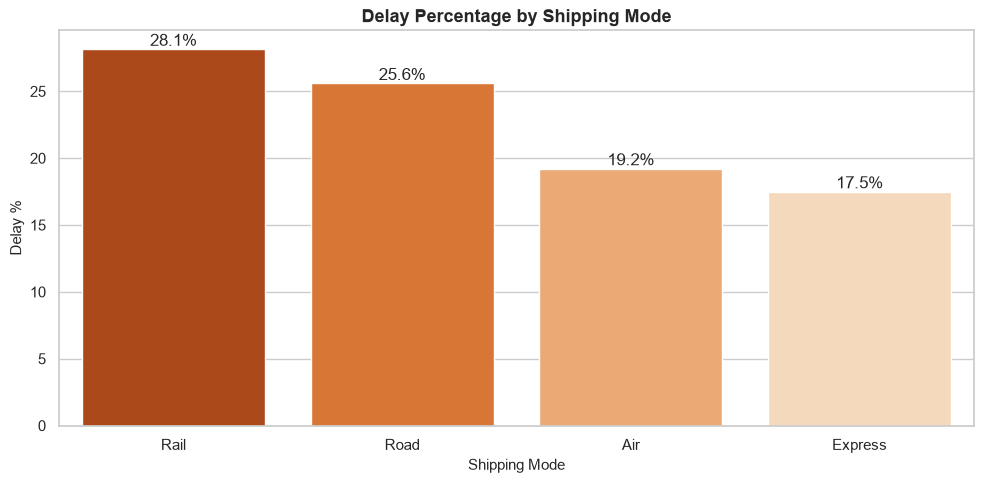

c:\Users\user\Downloads\vscode\Logistics Delivery Performance & Cost Analytics\src\visualization.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=grp.index, y=grp.values, palette="Blues_r")


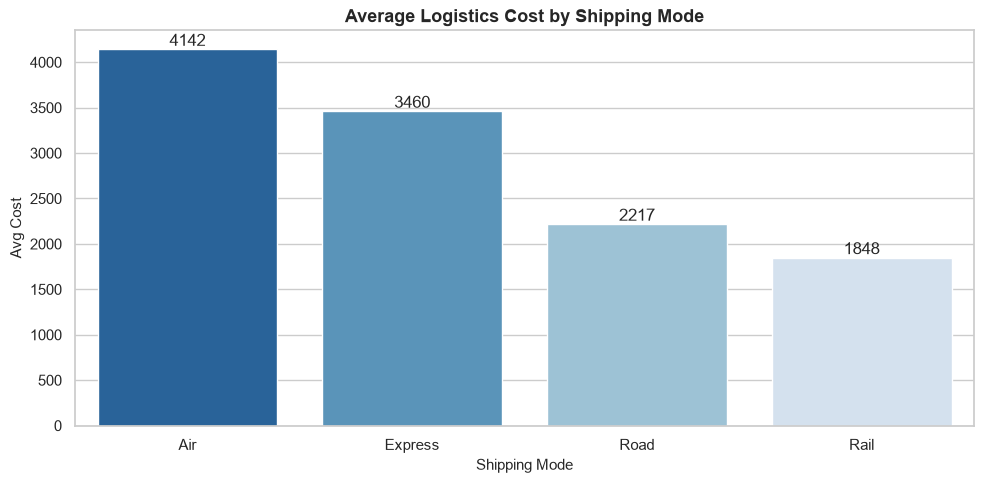

c:\Users\user\Downloads\vscode\Logistics Delivery Performance & Cost Analytics\src\visualization.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette="Set3")


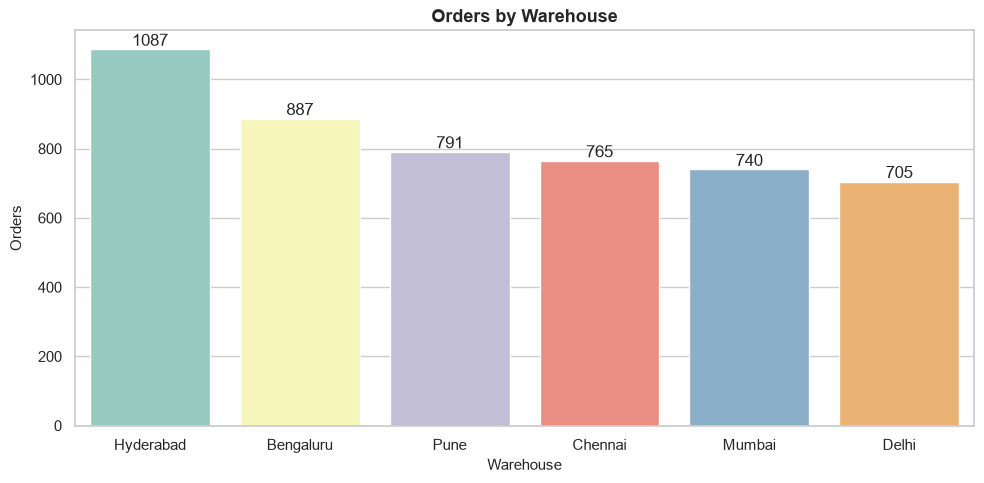

c:\Users\user\Downloads\vscode\Logistics Delivery Performance & Cost Analytics\src\visualization.py:173: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=grp.index, y=grp.values, palette="Greens_r")


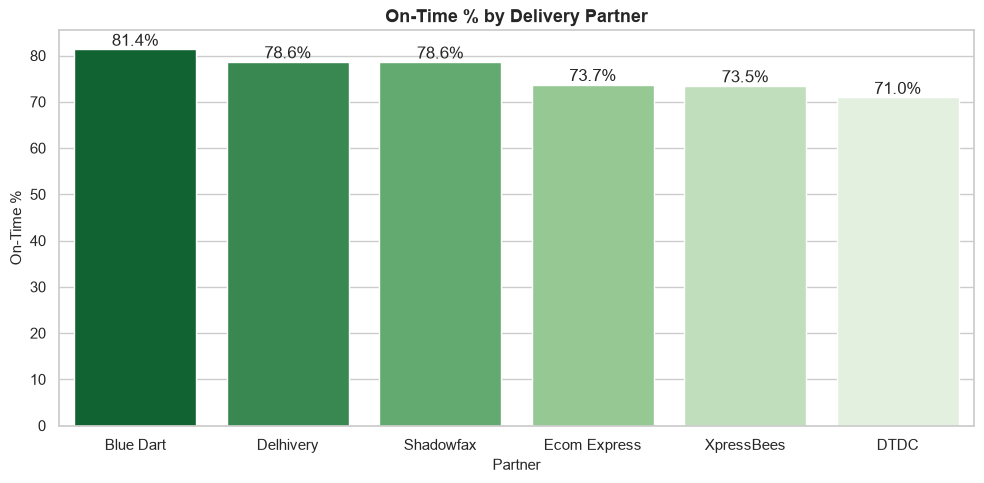

c:\Users\user\Downloads\vscode\Logistics Delivery Performance & Cost Analytics\src\visualization.py:194: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="customer_rating", data=df, palette="coolwarm")


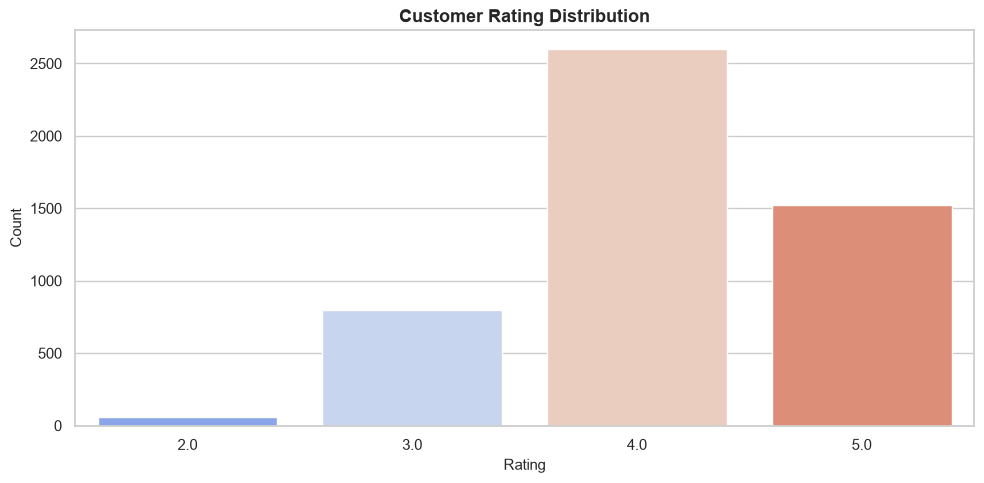

c:\Users\user\Downloads\vscode\Logistics Delivery Performance & Cost Analytics\src\visualization.py:202: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=grp.index, y=grp.values, palette="coolwarm")


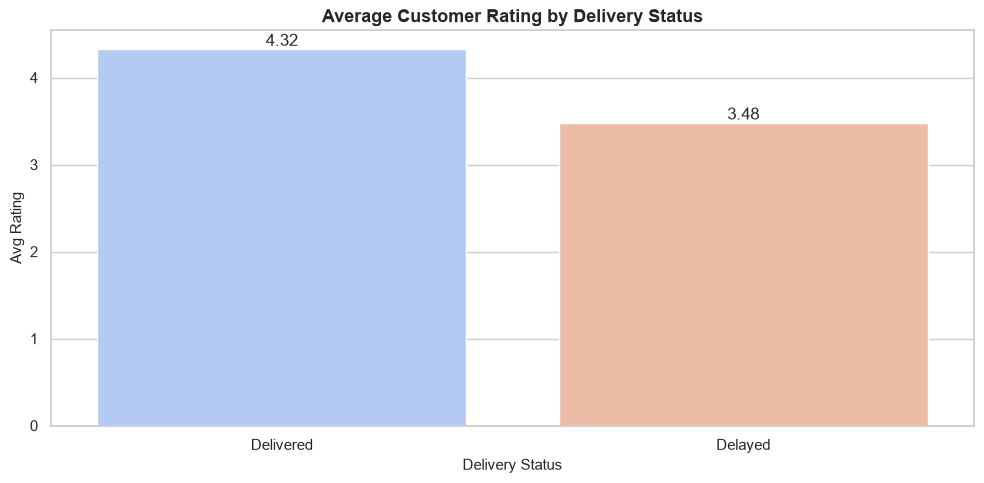

In [7]:
from src.visualization import *
plot_delivery_status(df)
plot_delay_by_warehouse(df)
plot_delay_by_shipping_mode(df)
plot_cost_by_shipping_mode(df)
plot_orders_by_warehouse(df)
plot_partner_delivery_performance(df)
plot_customer_rating_distribution(df)
plot_rating_by_delivery_status(df)

## Key Insights
- On-time delivery rate indicates overall operational reliability.
- Warehouses with the highest delay % need process review.
- Air shipping is fastest but most expensive — reserve it for urgent orders.
- Top partners by on-time % should be prioritised for volume allocation.
- Customer ratings drop significantly on delayed orders.

## Recommendations
1. Review dispatch workflow at top-delay warehouses.
2. Renegotiate rates with high-cost delivery partners.
3. Encourage Rail for long-distance non-urgent shipments.
4. Introduce SLA-based alerts for shipments approaching expected date.
5. Investigate the correlation between weight/distance and delay.

# Logistics Delivery Performance & Cost Analytics — Business Report

## 1. Executive Summary
This analysis examines the company's shipment data to quantify delivery
performance, delay patterns, cost distribution, warehouse efficiency,
and delivery-partner behaviour. It converts raw operational data into
actionable KPIs and business recommendations.

## 2. Business Problem
The organisation lacked visibility into where delays and costs originate
across routes, warehouses, shipping modes and partners.

## 3. Data Summary
- ~5,000+ order records
- Fields: order/customer IDs, dates, warehouse, origin/destination, distance,
  product category, quantity, weight, shipping mode, delivery partner,
  shipping cost, fuel cost, warehouse processing hours, delivery status,
  customer rating, damage flag, return flag.

## 4. Data Quality Findings
- Missing values in `shipping_cost`, `fuel_cost`, `customer_rating`
- Inconsistent text casing (`road`, `ROAD`, `Road`)
- Negative `shipping_cost` and `distance_km` values
- Dates stored as strings
- Some duplicate order IDs

## 5. Cleaning Performed
- Missing values imputed (median/mode) or rows dropped on critical IDs
- Duplicates removed
- Text columns standardised (title-case, trimmed)
- Dates parsed to datetime with logical validation
- Numeric validation & clamping
- Derived columns created: `delivery_days`, `delay_days`, `cost_per_km`,
  `total_logistics_cost`, `on_time_flag`

## 6. KPI Summary
| KPI | Value |
|---|---|
| Total Orders | (from data) |
| Delivered Orders | (from data) |
| Delayed Orders | (from data) |
| On-Time % | (from data) |
| Avg Delivery Days | (from data) |
| Avg Delay Days | (from data) |
| Total Logistics Cost | (from data) |
| Avg Logistics Cost | (from data) |
| Damage Rate | (from data) |
| Return Rate | (from data) |

## 7. Key Findings
- On-time delivery rate indicates overall reliability.
- Certain warehouses consistently show higher delay percentages.
- Air shipping is the fastest but most expensive mode.
- Rail is cheapest for long distances.
- Some delivery partners show significantly higher damage rates.
- Delayed shipments correlate with lower customer ratings.

## 8. Business Recommendations
1. Audit top-delay warehouses (processing time, staffing, handoff).
2. Renegotiate rates with expensive partners; review damage SLAs.
3. Promote Rail for long-haul non-urgent shipments.
4. Introduce predictive SLA alerts for at-risk shipments.
5. Reduce returns by improving packaging for high-damage categories.

## 9. Conclusion
The cleaned dataset and dashboard deliver a reliable operational view.
Management can now prioritise warehouses, routes, modes and partners
for targeted improvement and cost optimisation.